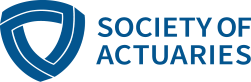

# 🎯 04 Climate Calibration

|                  |                                                                                             |
| ---------------- | ------------------------------------------------------------------------------------------- |
| Title            | 04 Climate Calibration                                                                      |
| Case Study       | Climate-Adjusted Mortality for Selected EU Countries                                        |
| Research Project | CC230 Quantifying Mortality and Morbidity Impacts from Climate Risks                       |
| Notebook         | `04_climate_calibration.ipynb`                                                              |
| Authors          | Carlos Arocha, FSA, SCR                                                                     |
| Sponsor          | Catastrophe and Climate Strategic Research Program, Society of Actuaries Research Institute |
| Version          | `v1.0.0`                                                                                    |
| Questions?       | Questions regarding this notebook should be directed to the SOA project contact             |

---

## Purpose

This notebook calibrates the climate-sensitivity parameter $λ_{x, r}$ by linking the baseline mortality residuals from Notebook 03 to the historical climate index $C_{t, r}$ produced by Notebook 02.

Notebook 01 remains the single source of parameters and file definitions. This notebook reads `data/interim/run_config.json`, `data/interim/input_manifest.csv`, `data/interim/02_climate_features_output_manifest.csv`, and `data/interim/03_baseline_mortality_model_output_manifest.csv`.

---

## Inputs

- Historical climate index $C_{t,r}$ from Notebook 02
- Baseline mortality residuals from Notebook 03
- Case-study parameters from Notebook 01

---

## Outputs

- Calibrated $\lambda_{x,r}$ parameters
- Climate calibration panel
- Calibration diagnostics
- Climate-adjusted fitted mortality values
- Notebook 4 output manifest for downstream notebooks

Report:
- `CC230 Toolkit/reports/{NOTEBOOK}.html`

---

## Dependencies

This notebook can be run in Google Colab or any compatible Jupyter environment, such as:

* JupyterLab
* Jupyter Notebook
* VS Code with the Jupyter extension
* Anaconda Navigator
* Kaggle Notebooks

The notebook was developed using:

* Python 3.14.5
* Required libraries installed through the setup cell below

---

## Disclaimer
The Jupyter notebooks available through this repository are provided for research, educational, and illustrative purposes only. They are not intended to constitute actuarial advice or to represent production-ready systems without further validation, customization, and governance by the user.

While reasonable efforts have been made to ensure accuracy and consistency, no guarantee is given as to completeness, fitness for a particular purpose, or compliance with applicable actuarial standards or regulatory requirements.

Users are responsible for assessing the suitability of the materials for their specific use cases and for implementing appropriate controls, validation, and documentation prior to any operational use.

---

## License
© 2026 Society of Actuaries. Except where otherwise noted, the textual content of this book is licensed under the Creative Commons Attribution–Noncommercial–Share Alike 4.0 International License (CC BY-NC-SA 4.0). Source code samples, including scripts, notebooks, and code blocks where indicated, are licensed under the MIT License, unless otherwise stated.

---

## Setup and Shared Configuration

In [1]:
# Setup and shared configuration

from pathlib import Path, PureWindowsPath
import json
from datetime import datetime, UTC

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import subprocess
import sys

PROJECT_ROOT = Path.cwd().parent.resolve()

if PROJECT_ROOT.parts[-1] != "CC230 Toolkit":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent.resolve()

INTERIM_DATA_PATH = PROJECT_ROOT / "data" / "interim"

run_config_file = INTERIM_DATA_PATH / "run_config.json"
input_manifest_file = INTERIM_DATA_PATH / "input_manifest.csv"
notebook1_output_manifest_file = INTERIM_DATA_PATH / "output_manifest.csv"
notebook2_output_manifest_file = INTERIM_DATA_PATH / "02_climate_features_output_manifest.csv"
notebook3_output_manifest_file = INTERIM_DATA_PATH / "03_baseline_mortality_model_output_manifest.csv"

NOTEBOOK_FILE = PROJECT_ROOT / "notebooks" / "04_climate_calibration.ipynb"    

required_control_files = {
    "run_config": run_config_file,
    "input_manifest": input_manifest_file,
    "notebook2_output_manifest": notebook2_output_manifest_file,
    "notebook3_output_manifest": notebook3_output_manifest_file,
}

for label, file_path in required_control_files.items():
    if not file_path.exists():
        raise FileNotFoundError(
            f"Missing {label}: {file_path}. "
            "Run the preceding notebooks in sequence: "
            "01_data_ingestion_and_preparation.ipynb, "
            "02_climate_features.ipynb, and "
            "03_baseline_mortality_model.ipynb."
        )

with open(run_config_file, "r", encoding="utf-8") as f:
    RUN_CONFIG = json.load(f)

input_manifest = pd.read_csv(input_manifest_file)
notebook1_output_manifest = (
    pd.read_csv(notebook1_output_manifest_file)
    if notebook1_output_manifest_file.exists()
    else pd.DataFrame()
)
notebook2_output_manifest = pd.read_csv(notebook2_output_manifest_file)
notebook3_output_manifest = pd.read_csv(notebook3_output_manifest_file)

pd.set_option("display.max_columns", None)
np.set_printoptions(suppress=True)

print("Loaded control files:")
for file_path in [
    run_config_file,
    input_manifest_file,
    notebook2_output_manifest_file,
    notebook3_output_manifest_file,
]:
    print(" -", PureWindowsPath(file_path).name)

Loaded control files:
 - run_config.json
 - input_manifest.csv
 - 02_climate_features_output_manifest.csv
 - 03_baseline_mortality_model_output_manifest.csv


## Settings Imported from Notebook 01

The calibration period, excluded years, countries, age range, scenario, and file-name labels are read from `run_config.json`. This avoids re-entering parameters manually in Notebook 04.

In [2]:
# Settings from Notebook 01

DATA_PATH = Path(RUN_CONFIG["data_path"])
RAW_DATA_PATH = Path(RUN_CONFIG["raw_data_path"])
PROCESSED_DATA_PATH = Path(RUN_CONFIG["processed_data_path"])
OUTPUT_PATH = Path(RUN_CONFIG["output_path"])

REPORTS_PATH = PROJECT_ROOT / "reports"

SCENARIO = RUN_CONFIG["scenario"]
COUNTRIES = RUN_CONFIG["countries"]

CALIBRATION_START_YEAR = int(RUN_CONFIG["calibration_start_year"])
CALIBRATION_END_YEAR = int(RUN_CONFIG["calibration_end_year"])
EXCLUDED_CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["excluded_calibration_years"]]
CALIBRATION_YEARS = [int(y) for y in RUN_CONFIG["calibration_years"]]
CALIBRATION_YEARS_LABEL = RUN_CONFIG["calibration_years_label"]
N_CALIBRATION_YEARS = int(RUN_CONFIG["n_calibration_years"])

AGE_MIN = int(RUN_CONFIG["age_min"])
AGE_MAX = int(RUN_CONFIG["age_max"])
AGE_RANGE_LABEL = RUN_CONFIG["age_range_label"]

# Calibration options
# Because Notebook 03 currently works with mortality rates only, exposure weights
# are not expected. If an exposure column is later added to the residual file,
# this notebook can use it by changing USE_EXPOSURE_WEIGHTS to True.
MIN_OBS_PER_GROUP = min(8, max(3, N_CALIBRATION_YEARS // 2))
USE_NO_INTERCEPT = True
USE_EXPOSURE_WEIGHTS = False

# Name of the climate-index column produced by Notebook 2.
C_COLUMN = "C_tr_core"

# Notebook 4 output files
lambda_out = OUTPUT_PATH / f"climate_parameters_lambda_xr_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
panel_out = OUTPUT_PATH / f"climate_calibration_panel_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
diagnostics_out = OUTPUT_PATH / f"climate_calibration_diagnostics_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
summary_out = OUTPUT_PATH / f"climate_calibration_summary_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"
adjusted_fit_out = OUTPUT_PATH / f"climate_adjusted_fitted_mortality_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.csv"

notebook4_output_manifest_file = INTERIM_DATA_PATH / "04_climate_calibration_output_manifest.csv"

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

RUN_METADATA = {
    "notebook": "04_climate_calibration.ipynb",
    "run_timestamp_utc": datetime.now(UTC).isoformat(),
    "project_root": str(PROJECT_ROOT),
    "scenario": SCENARIO,
    "countries": COUNTRIES,
    "calibration_years": CALIBRATION_YEARS,
    "excluded_calibration_years": EXCLUDED_CALIBRATION_YEARS,
    "age_min": AGE_MIN,
    "age_max": AGE_MAX,
    "climate_index_column": C_COLUMN,
    "use_no_intercept": USE_NO_INTERCEPT,
    "use_exposure_weights": USE_EXPOSURE_WEIGHTS,
    "min_obs_per_group": MIN_OBS_PER_GROUP,
}

print(json.dumps(RUN_METADATA, indent=2))

{
  "notebook": "04_climate_calibration.ipynb",
  "run_timestamp_utc": "2026-06-19T14:12:09.735383+00:00",
  "project_root": "C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit",
  "scenario": "ssp5_8_5",
  "countries": [
    "ES",
    "FR",
    "IT"
  ],
  "calibration_years": [
    2004,
    2005,
    2006,
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2022,
    2023,
    2024,
    2025
  ],
  "excluded_calibration_years": [
    2020,
    2021
  ],
  "age_min": 20,
  "age_max": 85,
  "climate_index_column": "C_tr_core",
  "use_no_intercept": true,
  "use_exposure_weights": false,
  "min_obs_per_group": 8
}


## Helper Functions and Input Checks

The helper functions below retrieve input files from the manifests, validate required columns, and create the output manifest used by downstream notebooks.

In [3]:
# Helper functions and input checks

def ensure_columns(df, required_cols, label):
    missing = set(required_cols) - set(df.columns)
    if missing:
        raise ValueError(f"{label} is missing required columns: {sorted(missing)}")

def path_to_project_relative(path):
    path = Path(path)
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except ValueError:
        return str(path)

def register_file(role, path, file_type="csv", required=True, stage="output", notes=None):
    path = Path(path)
    return {
        "stage": stage,
        "role": role,
        "file_name": path.name,
        "relative_path": path_to_project_relative(path),
        "absolute_path": str(path),
        "file_type": file_type,
        "required": bool(required),
        "exists": path.exists(),
        "notes": notes,
    }

def require_file(path, label):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Required file not found for {label}: {path}. "
            "Run the preceding notebooks and review the manifest files."
        )
    return path

def get_manifest_path(manifest, role, label):
    if manifest.empty:
        raise ValueError(f"{label} manifest is empty. Cannot locate role '{role}'.")

    matches = manifest[manifest["role"].astype(str).eq(role)].copy()

    if matches.empty:
        available_roles = sorted(manifest["role"].astype(str).unique())
        raise ValueError(
            f"Role '{role}' was not found in {label} manifest. "
            f"Available roles: {available_roles}"
        )

    row = matches.iloc[0]
    candidate_paths = []

    if "absolute_path" in row and pd.notna(row["absolute_path"]):
        candidate_paths.append(Path(row["absolute_path"]))

    if "relative_path" in row and pd.notna(row["relative_path"]):
        candidate_paths.append(PROJECT_ROOT / str(row["relative_path"]))

    for candidate in candidate_paths:
        if candidate.exists():
            return candidate

    if candidate_paths:
        return candidate_paths[0]

    raise ValueError(f"No usable path found for role '{role}' in {label} manifest.")


climate_feature_file = get_manifest_path(
    notebook2_output_manifest,
    role="climate_index_combined",
    label="Notebook 2 output",
)

baseline_residual_file = get_manifest_path(
    notebook3_output_manifest,
    role="baseline_residuals",
    label="Notebook 3 output",
)

baseline_fit_file = get_manifest_path(
    notebook3_output_manifest,
    role="baseline_fitted_mortality",
    label="Notebook 3 output",
)

require_file(climate_feature_file, "Notebook 2 climate-index output")
require_file(baseline_residual_file, "Notebook 3 baseline residual output")
require_file(baseline_fit_file, "Notebook 3 baseline fitted mortality output")

print("Required Notebook 4 input files:")
print(" - Climate index:", PureWindowsPath(climate_feature_file).name)
print(" - Baseline residuals:", PureWindowsPath(baseline_residual_file).name)
print(" - Baseline fitted mortality:", PureWindowsPath(baseline_fit_file).name)

Required Notebook 4 input files:
 - Climate index: C_tr_core_country_annual_combined_era5_cmip6_ssp5_8_5.csv
 - Baseline residuals: baseline_residuals_2004_2025_excl_2020_2021_age20_85.csv
 - Baseline fitted mortality: baseline_fitted_mortality_2004_2025_excl_2020_2021_age20_85.csv


## Load Baseline Residuals

The calibration uses the baseline residuals from Notebook 03 as the response variable. These residuals represent the portion of log mortality not explained by the baseline Lee-Carter structure.

In [4]:
# Load baseline residuals

resid = pd.read_csv(baseline_residual_file)

resid.columns = (
    resid.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

ensure_columns(
    resid,
    required_cols={"country", "year", "age", "baseline_residual"},
    label="Baseline residual file",
)

if "age_num" not in resid.columns:
    resid["age_num"] = (
        resid["age"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(float)
    )

resid["year"] = pd.to_numeric(resid["year"], errors="coerce")
resid["age_num"] = pd.to_numeric(resid["age_num"], errors="coerce")
resid["baseline_residual"] = pd.to_numeric(resid["baseline_residual"], errors="coerce")

for col in ["mx", "log_mx", "mx_hat_baseline", "log_mx_hat_baseline"]:
    if col in resid.columns:
        resid[col] = pd.to_numeric(resid[col], errors="coerce")

resid = resid[
    resid["country"].isin(COUNTRIES)
    & resid["year"].isin(CALIBRATION_YEARS)
    & resid["age_num"].between(AGE_MIN, AGE_MAX)
    & resid["baseline_residual"].notna()
    & resid["age_num"].notna()
].copy()

resid["year"] = resid["year"].astype(int)
resid["age_num"] = resid["age_num"].astype(float)

print("Prepared residual panel:")
print("Rows:", len(resid))
print("Countries:", sorted(resid["country"].unique()))
print("Years:", sorted(resid["year"].unique()))
print("Age range:", resid["age_num"].min(), "to", resid["age_num"].max())

Prepared residual panel:
Rows: 3960
Countries: ['ES', 'FR', 'IT']
Years: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Age range: 20.0 to 85.0


## Load Historical Climate-Index Data

The climate feature used for calibration is $C_{t,r}$ from Notebook 02. Only historical years included in the calibration period are used.

In [5]:
# Load cliamte feature data

climate = pd.read_csv(climate_feature_file)

climate.columns = (
    climate.columns
    .str.strip()
    .str.replace(" ", "_")
)

rename_map = {}
for col in climate.columns:
    if col.lower() == "country":
        rename_map[col] = "country"
    if col.lower() == "year":
        rename_map[col] = "year"

if rename_map:
    climate = climate.rename(columns=rename_map)

ensure_columns(
    climate,
    required_cols={"country", "year", C_COLUMN},
    label="Climate feature file",
)

climate["year"] = pd.to_numeric(climate["year"], errors="coerce")
climate[C_COLUMN] = pd.to_numeric(climate[C_COLUMN], errors="coerce")

climate_hist = climate[
    climate["country"].isin(COUNTRIES)
    & climate["year"].isin(CALIBRATION_YEARS)
].copy()

if "period_type" in climate_hist.columns:
    climate_hist = climate_hist[
        climate_hist["period_type"].astype(str).str.lower().eq("historical")
    ].copy()

cols_to_keep = ["country", "year", C_COLUMN]
cols_to_keep += [
    col
    for col in ["source", "scenario", "period_type", "standardization_period", "standardization_source"]
    if col in climate_hist.columns
]

climate_hist = climate_hist[cols_to_keep].copy()
climate_hist = climate_hist.rename(columns={C_COLUMN: "C_tr"})
climate_hist = climate_hist[climate_hist["C_tr"].notna()].copy()
climate_hist["year"] = climate_hist["year"].astype(int)

print("Prepared historical climate-index data:")
print("Rows:", len(climate_hist))
print("Countries:", sorted(climate_hist["country"].unique()))
print("Years:", sorted(climate_hist["year"].unique()))

if "period_type" in climate_hist.columns:
    print("Period types:", sorted(climate_hist["period_type"].dropna().astype(str).unique()))

Prepared historical climate-index data:
Rows: 60
Countries: ['ES', 'FR', 'IT']
Years: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Period types: ['historical']


## Build the Calibration Panel

The calibration panel joins the baseline mortality residuals with $C_{t,r}$ at country-year level. The resulting panel is indexed by country, age, and year.

In [6]:
# Merge baseline residuals with C_{t,r}

calib_panel = resid.merge(
    climate_hist[["country", "year", "C_tr"]],
    on=["country", "year"],
    how="inner",
)

calib_panel = calib_panel[
    calib_panel["C_tr"].notna()
    & calib_panel["baseline_residual"].notna()
].copy()

if calib_panel.empty:
    raise ValueError(
        "Calibration panel is empty after merging residuals with C_tr. "
        "Check that Notebook 2 and Notebook 3 use the same countries and calibration years."
    )

print("Calibration panel:")
print("Rows:", len(calib_panel))
print("Countries:", sorted(calib_panel["country"].unique()))
print("Years:", sorted(calib_panel["year"].unique()))
print("Age range:", calib_panel["age_num"].min(), "to", calib_panel["age_num"].max())

coverage = (
    calib_panel
    .groupby(["country", "year"], as_index=False)
    .size()
    .rename(columns={"size": "age_rows"})
)

Calibration panel:
Rows: 3960
Countries: ['ES', 'FR', 'IT']
Years: [np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Age range: 20.0 to 85.0


## Estimate $\lambda_{x,r}$

For each country and age, the notebook estimates $\lambda_{x,r}$ from the relationship between the baseline residual and $C_{t,r}$. By default, the regression is estimated without an intercept so that the climate component is interpreted as an incremental adjustment to the baseline model.

In [7]:
# Estimate lambda_{x,r}

def estimate_lambda_for_group(g, use_no_intercept=True, use_weights=False):
    g = g.dropna(subset=["baseline_residual", "C_tr"]).copy()

    n_obs = len(g)

    base_result = {
        "n_obs": n_obs,
        "weighted": bool(use_weights),
        "intercept": np.nan,
        "r_squared": np.nan,
        "rmse_residual_after_climate": np.nan,
        "mean_C_tr": g["C_tr"].mean() if n_obs > 0 else np.nan,
        "sd_C_tr": g["C_tr"].std(ddof=0) if n_obs > 1 else np.nan,
    }

    if n_obs < MIN_OBS_PER_GROUP:
        return {
            **base_result,
            "lambda_xr": np.nan,
            "status": "insufficient_observations",
        }

    y = g["baseline_residual"].astype(float).values
    x = g["C_tr"].astype(float).values

    if np.isclose(np.nanvar(x), 0):
        return {
            **base_result,
            "lambda_xr": np.nan,
            "status": "zero_variance_C_tr",
        }

    if use_weights and "exposure" in g.columns:
        w = g["exposure"].astype(float).values
        w = np.where(np.isfinite(w) & (w > 0), w, 1.0)
    else:
        w = np.ones_like(y)

    if use_no_intercept:
        denom = np.sum(w * x * x)
        lambda_hat = np.nan if np.isclose(denom, 0) else np.sum(w * x * y) / denom
        intercept_hat = 0.0
        y_hat = lambda_hat * x
    else:
        X = np.column_stack([np.ones_like(x), x])
        W_sqrt = np.sqrt(w)
        Xw = X * W_sqrt[:, None]
        yw = y * W_sqrt
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        intercept_hat = beta[0]
        lambda_hat = beta[1]
        y_hat = intercept_hat + lambda_hat * x

    residual_after = y - y_hat

    ss_res = np.sum(w * residual_after**2)
    y_mean_w = np.average(y, weights=w)
    ss_tot = np.sum(w * (y - y_mean_w)**2)

    r_squared = np.nan if np.isclose(ss_tot, 0) else 1 - ss_res / ss_tot
    rmse = np.sqrt(np.average(residual_after**2, weights=w))

    return {
        "lambda_xr": lambda_hat,
        "n_obs": n_obs,
        "weighted": bool(use_weights),
        "intercept": intercept_hat,
        "r_squared": r_squared,
        "rmse_residual_after_climate": rmse,
        "mean_C_tr": np.nanmean(x),
        "sd_C_tr": np.nanstd(x),
        "status": "estimated",
    }

records = []

for (country, age, age_num), g in calib_panel.groupby(["country", "age", "age_num"], sort=True):
    result = estimate_lambda_for_group(
        g,
        use_no_intercept=USE_NO_INTERCEPT,
        use_weights=USE_EXPOSURE_WEIGHTS,
    )

    records.append({
        "country": country,
        "age": age,
        "age_num": age_num,
        **result,
    })

lambda_xr = pd.DataFrame(records)
lambda_xr = lambda_xr.sort_values(["country", "age_num"]).reset_index(drop=True)

print("Lambda-estimation status:")
print(lambda_xr["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count"))

Lambda-estimation status:
      status  count
0  estimated    198


## Attach Calibrated $\lambda_{x,r}$ and Compute Climate-Adjusted Fitted Values

In [8]:
# Attach calibrated lambda_{x,r}

calib_panel = calib_panel.merge(
    lambda_xr[["country", "age", "age_num", "lambda_xr"]],
    on=["country", "age", "age_num"],
    how="left",
)

calib_panel["climate_component"] = (
    calib_panel["lambda_xr"] * calib_panel["C_tr"]
)

calib_panel["residual_after_climate"] = (
    calib_panel["baseline_residual"] - calib_panel["climate_component"]
)

if "log_mx_hat_baseline" in calib_panel.columns:
    calib_panel["log_mx_hat_climate_adjusted"] = (
        calib_panel["log_mx_hat_baseline"]
        + calib_panel["climate_component"]
    )

    calib_panel["mx_hat_climate_adjusted"] = np.exp(
        calib_panel["log_mx_hat_climate_adjusted"]
    )

print("Calibrated lambda successfully attached")    

Calibrated lambda successfully attached


## Diagnostics

The diagnostics compare the residual pattern before and after adding the calibrated climate component. These diagnostics are intended to support reasonableness checks, sensitivity analysis, and model governance.

In [9]:
 # Calibration diagnostics

required_cols = {
    "country",
    "year",
    "baseline_residual",
    "residual_after_climate",
    "C_tr",
}

missing_cols = required_cols - set(calib_panel.columns)
if missing_cols:
    raise ValueError(f"calib_panel is missing required columns: {missing_cols}")

for col in ["year", "baseline_residual", "residual_after_climate", "C_tr"]:
    calib_panel[col] = pd.to_numeric(calib_panel[col], errors="coerce")

calib_panel = calib_panel[
    calib_panel["baseline_residual"].notna()
    & calib_panel["residual_after_climate"].notna()
    & calib_panel["C_tr"].notna()
].copy()

def rmse(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return np.sqrt(np.mean(x**2))

def mae(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return np.mean(np.abs(x))

diagnostics_country_year = (
    calib_panel
    .groupby(["country", "year"], as_index=False)
    .agg(
        n_obs=("baseline_residual", "size"),
        C_tr=("C_tr", "mean"),
        mean_baseline_residual=("baseline_residual", "mean"),
        rmse_baseline_residual=("baseline_residual", rmse),
        mae_baseline_residual=("baseline_residual", mae),
        mean_residual_after_climate=("residual_after_climate", "mean"),
        rmse_residual_after_climate=("residual_after_climate", rmse),
        mae_residual_after_climate=("residual_after_climate", mae),
    )
)

diagnostics_country_year["rmse_change"] = (
    diagnostics_country_year["rmse_residual_after_climate"]
    - diagnostics_country_year["rmse_baseline_residual"]
)

diagnostics_country_year["rmse_change_pct"] = np.where(
    diagnostics_country_year["rmse_baseline_residual"] != 0,
    100
    * diagnostics_country_year["rmse_change"]
    / diagnostics_country_year["rmse_baseline_residual"],
    np.nan,
)

diagnostics_country_year["mae_change"] = (
    diagnostics_country_year["mae_residual_after_climate"]
    - diagnostics_country_year["mae_baseline_residual"]
)

diagnostics_country_year["mae_change_pct"] = np.where(
    diagnostics_country_year["mae_baseline_residual"] != 0,
    100
    * diagnostics_country_year["mae_change"]
    / diagnostics_country_year["mae_baseline_residual"],
    np.nan,
)

# Diagnostics by country

diagnostics_country = (
    calib_panel
    .groupby("country", as_index=False)
    .agg(
        n_obs=("baseline_residual", "size"),
        n_years=("year", "nunique"),
        mean_C_tr=("C_tr", "mean"),
        mean_baseline_residual=("baseline_residual", "mean"),
        rmse_baseline_residual=("baseline_residual", rmse),
        mae_baseline_residual=("baseline_residual", mae),
        mean_residual_after_climate=("residual_after_climate", "mean"),
        rmse_residual_after_climate=("residual_after_climate", rmse),
        mae_residual_after_climate=("residual_after_climate", mae),
    )
)

diagnostics_country["rmse_change"] = (
    diagnostics_country["rmse_residual_after_climate"]
    - diagnostics_country["rmse_baseline_residual"]
)

diagnostics_country["rmse_change_pct"] = np.where(
    diagnostics_country["rmse_baseline_residual"] != 0,
    100
    * diagnostics_country["rmse_change"]
    / diagnostics_country["rmse_baseline_residual"],
    np.nan,
)

# Diagnostics by age

age_col = "age_num" if "age_num" in calib_panel.columns else "age"

diagnostics_age = (
    calib_panel
    .groupby(age_col, as_index=False)
    .agg(
        n_obs=("baseline_residual", "size"),
        mean_baseline_residual=("baseline_residual", "mean"),
        rmse_baseline_residual=("baseline_residual", rmse),
        mae_baseline_residual=("baseline_residual", mae),
        mean_residual_after_climate=("residual_after_climate", "mean"),
        rmse_residual_after_climate=("residual_after_climate", rmse),
        mae_residual_after_climate=("residual_after_climate", mae),
    )
)

diagnostics_age["rmse_change"] = (
    diagnostics_age["rmse_residual_after_climate"]
    - diagnostics_age["rmse_baseline_residual"]
)

diagnostics_age["rmse_change_pct"] = np.where(
    diagnostics_age["rmse_baseline_residual"] != 0,
    100
    * diagnostics_age["rmse_change"]
    / diagnostics_age["rmse_baseline_residual"],
    np.nan,
)

# Overall summary

overall_rmse_before = rmse(calib_panel["baseline_residual"])
overall_rmse_after = rmse(calib_panel["residual_after_climate"])

overall_mae_before = mae(calib_panel["baseline_residual"])
overall_mae_after = mae(calib_panel["residual_after_climate"])

summary = pd.DataFrame({
    "metric": [
        "n_observations",
        "n_countries",
        "first_calibration_year",
        "last_calibration_year",
        "n_lambda_estimated",
        "n_lambda_missing",
        "mean_baseline_residual",
        "mean_residual_after_climate",
        "rmse_baseline_residual",
        "rmse_residual_after_climate",
        "rmse_change",
        "rmse_change_pct",
        "mae_baseline_residual",
        "mae_residual_after_climate",
        "mae_change",
        "mae_change_pct",
    ],
    "value": [
        len(calib_panel),
        calib_panel["country"].nunique(),
        int(calib_panel["year"].min()),
        int(calib_panel["year"].max()),
        lambda_xr["lambda_xr"].notna().sum(),
        lambda_xr["lambda_xr"].isna().sum(),
        calib_panel["baseline_residual"].mean(),
        calib_panel["residual_after_climate"].mean(),
        overall_rmse_before,
        overall_rmse_after,
        overall_rmse_after - overall_rmse_before,
        100 * (overall_rmse_after - overall_rmse_before) / overall_rmse_before
        if overall_rmse_before != 0 else np.nan,
        overall_mae_before,
        overall_mae_after,
        overall_mae_after - overall_mae_before,
        100 * (overall_mae_after - overall_mae_before) / overall_mae_before
        if overall_mae_before != 0 else np.nan,
    ]
})


# Display diagnostics

print("Overall calibration summary:")
print(summary)

print('-'*80)

print("Diagnostics by country:")
print(diagnostics_country.round(6))

Overall calibration summary:
                         metric         value
0                n_observations  3.960000e+03
1                   n_countries  3.000000e+00
2        first_calibration_year  2.004000e+03
3         last_calibration_year  2.025000e+03
4            n_lambda_estimated  1.980000e+02
5              n_lambda_missing  0.000000e+00
6        mean_baseline_residual  1.973730e-17
7   mean_residual_after_climate  2.018587e-17
8        rmse_baseline_residual  5.603609e-02
9   rmse_residual_after_climate  5.016420e-02
10                  rmse_change -5.871893e-03
11              rmse_change_pct -1.047877e+01
12        mae_baseline_residual  4.020535e-02
13   mae_residual_after_climate  3.526192e-02
14                   mae_change -4.943430e-03
15               mae_change_pct -1.229545e+01
--------------------------------------------------------------------------------
Diagnostics by country:
  country  n_obs  n_years  mean_C_tr  mean_baseline_residual  \
0      ES   1320    

## Diagnostic Plots

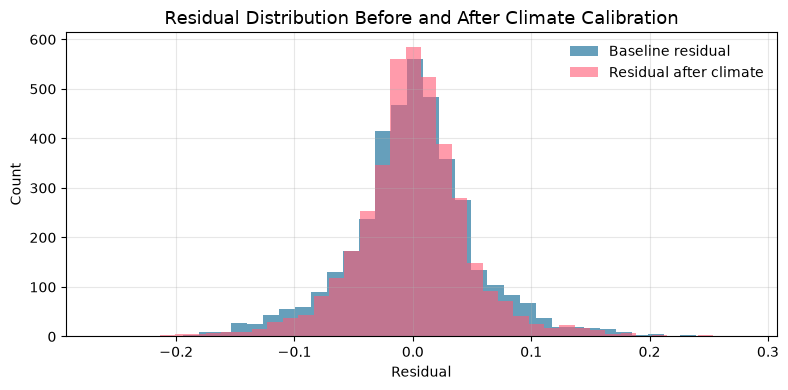

In [10]:
# Diagnostic plots

# Residual distribution
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(
    calib_panel["baseline_residual"].dropna(),
    bins=40,
    alpha=0.60,
    label="Baseline residual",
    color="#00608E"
)

ax.hist(
    calib_panel["residual_after_climate"].dropna(),
    bins=40,
    alpha=0.60,
    label="Residual after climate",
    color="#ff5974"
)

ax.set_title(
    "Residual Distribution Before and After Climate Calibration",
    fontsize=13
)

ax.set_xlabel("Residual")
ax.set_ylabel("Count")

ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

fig.tight_layout()

fig.savefig(
    OUTPUT_PATH / f"residual_distribution_{CALIBRATION_YEARS_LABEL}_{AGE_RANGE_LABEL}.svg",
    format="svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

## Save outputs

In [11]:
# Save outputs

lambda_xr.to_csv(lambda_out, index=False)
calib_panel.to_csv(panel_out, index=False)
diagnostics_country_year.to_csv(diagnostics_out, index=False)
summary.to_csv(summary_out, index=False)

adjusted_cols = [
    "country",
    "year",
    "age",
    "age_num",
    "mx",
    "log_mx",
    "mx_hat_baseline",
    "log_mx_hat_baseline",
    "baseline_residual",
    "C_tr",
    "lambda_xr",
    "climate_component",
    "residual_after_climate",
    "mx_hat_climate_adjusted",
    "log_mx_hat_climate_adjusted",
]

adjusted_cols = [
    col
    for col in adjusted_cols
    if col in calib_panel.columns
]

climate_adjusted_fit = calib_panel[adjusted_cols].copy()
climate_adjusted_fit.to_csv(adjusted_fit_out, index=False)

print("Saved climate calibration outputs:")
for file_path in [
    lambda_out,
    panel_out,
    diagnostics_out,
    summary_out,
    adjusted_fit_out,
]:
    print(f"  - {PureWindowsPath(file_path).name}")

Saved climate calibration outputs:
  - climate_parameters_lambda_xr_2004_2025_excl_2020_2021_age20_85.csv
  - climate_calibration_panel_2004_2025_excl_2020_2021_age20_85.csv
  - climate_calibration_diagnostics_2004_2025_excl_2020_2021_age20_85.csv
  - climate_calibration_summary_2004_2025_excl_2020_2021_age20_85.csv
  - climate_adjusted_fitted_mortality_2004_2025_excl_2020_2021_age20_85.csv


## Output Manifest

This final cell writes the Notebook 04 output manifest. Downstream notebooks should read this manifest rather than reconstructing file names manually.

In [12]:
# Output manifest and completion message

output_records = [
    register_file(
        role="climate_parameter_lambda_xr",
        path=lambda_out,
        notes="Estimated climate sensitivity parameter by age and country",
    ),
    register_file(
        role="climate_calibration_panel",
        path=panel_out,
        notes="Merged residual and climate-index calibration panel",
    ),
    register_file(
        role="climate_calibration_diagnostics",
        path=diagnostics_out,
        notes="Country-year calibration diagnostics",
    ),
    register_file(
        role="climate_calibration_summary",
        path=summary_out,
        notes="Summary of climate calibration outputs",
    ),
    register_file(
        role="climate_adjusted_fitted_mortality",
        path=adjusted_fit_out,
        notes="Baseline and climate-adjusted fitted mortality values",
    ),
]

notebook4_output_manifest = pd.DataFrame(output_records)
notebook4_output_manifest.to_csv(notebook4_output_manifest_file, index=False)

missing_outputs = notebook4_output_manifest[
    notebook4_output_manifest["required"].eq(True)
    & notebook4_output_manifest["exists"].eq(False)
].copy()

if not missing_outputs.empty:
    display(missing_outputs[["role", "file_name", "absolute_path"]])
    raise FileNotFoundError(
        "One or more expected Notebook 4 outputs were not created. Review the cells above."
    )

print("Saved Notebook 4 output manifest:")
print(PureWindowsPath(notebook4_output_manifest_file).name)

print("\n" + "=" * 78)
print("✅ NOTEBOOK 4 COMPLETE")
print("=" * 78)
print("Please review the calibrated lambda parameters, diagnostics, and output files listed above.")
print("Next step: run Notebook 5 — 05_projection_engine.ipynb")
print("=" * 78)

# Create report
subprocess.run(
    [
        sys.executable,
        "-m",
        "jupyter",
        "nbconvert",
        str(NOTEBOOK_FILE),
        "--to",
        "html",
        "--no-input",
        "--output-dir",
        str(REPORTS_PATH),
    ],
    check=True,
)

Saved Notebook 4 output manifest:
04_climate_calibration_output_manifest.csv

✅ NOTEBOOK 4 COMPLETE
Please review the calibrated lambda parameters, diagnostics, and output files listed above.
Next step: run Notebook 5 — 05_projection_engine.ipynb


CompletedProcess(args=['C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\.venv\\Scripts\\python.exe', '-m', 'jupyter', 'nbconvert', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\notebooks\\04_climate_calibration.ipynb', '--to', 'html', '--no-input', '--output-dir', 'C:\\Users\\ca\\OneDrive\\Documents\\@ PROJECTS\\CC230 Toolkit\\reports'], returncode=0)